# Integration of Station Data with PyEarthTools

This tutorial demonstrates how to create a data accessor for the station data which will integrate with PyEarthTools pipelines. In due course, a similar implementation will be put into the relevant site archive packages for people working in supported facilities, but this demonstrates how you can easily connect your own station data archive into the framework from first principles. Working with custom station datasets is relatively common (e.g. hydrology-specific data sets, different temporal resolutions, region-specific datasets, data sources not included in the global data sharing etc) and so seeing the entire process is of value.

This tutorial will show how to:

 - Create a data accessor on-the-fly in the notebook
 - Access and plot data
 - Access that data alongside gridded data, and plot the overlay


Note! The data visualised in this notebook is only showing a small subset of the total number of stations, as it was developed on limited data in the first instance. It will be updated in due course with the entire dataset.



In [1]:
import pyearthtools.data
import pyearthtools.pipeline
from pyearthtools.data import Petdt

from pathlib import Path
DECADAL_DIR = Path('/g/data/kd24/data') / 'hadisd' / 'by_decade' 
WBERA5_DIR = Path('/g/data/kd24/data') / 'wbera5' / 'by_decade' 

from mpl_toolkits.basemap import Basemap

In [2]:
from pyearthtools.data.archive import register_archive
from pyearthtools.data.exceptions import DataNotFoundError
from pyearthtools.data.indexes import ArchiveIndex, decorators
from pyearthtools.data.transforms import Transform, TransformCollection
import xarray as xr
import numpy as np

@register_archive("ISD", sample_kwargs=dict(variable="2t"))
class ISD(ArchiveIndex):
    @property
    def _desc_(self):
        return {
            "singleline": "Hadley Integrated Surface Database",
            "range": "1930 - 2025",
            "Documentation": "https://www.metoffice.gov.uk/hadobs/hadisd/",
        }

    def __init__(
        self,
        disk_location,
        *,        
        transforms: Transform | TransformCollection | None = None,
    ):

        self.disk_location = Path(disk_location)  # Location of the large groupings files
        super().__init__(transforms=transforms or TransformCollection())

    def filesystem(self, querytime: str | Petdt):
        '''
        This is quick, no need to cache it
        '''
        files = list(self.disk_location.glob('*1990*.nc'))
        return files

    def load(self, from_files_list, **kwargs):

        ds = xr.open_mfdataset(from_files_list, combine='nested', concat_dim='report')

        # Arguably, this should be a transform, or handled in the pipeline, but it works for now
        ds['temperatures'] = ds.temperatures.where(ds.temperatures > -1000)
        return ds

In [3]:

era5_source = pyearthtools.data.download.weatherbench.WB2ERA5(
        variables=["2m_temperature", "u", "v", "geopotential"],
        level=[850],
        download_dir=WBERA5_DIR,
        license_ok=True,
    ),

station_source = ISD(DECADAL_DIR)

data_pipeline = pyearthtools.pipeline.Pipeline(
    (era5_source, station_source)
)

In [4]:
# Here we see the pipeline returns the ERA5 grid and the station data as two separate datasets, at a matched time.
data_pipeline['19900620T00']

(<xarray.Dataset> Size: 34kB
 Dimensions:              (time: 1, longitude: 64, latitude: 32, level: 1)
 Coordinates:
   * time                 (time) datetime64[ns] 8B 1990-06-20
   * longitude            (longitude) float64 512B 0.0 5.625 ... 348.8 354.4
   * latitude             (latitude) float64 256B -87.19 -81.56 ... 81.56 87.19
   * level                (level) int64 8B 850
 Data variables:
     2m_temperature       (time, longitude, latitude) float32 8kB dask.array<chunksize=(1, 64, 32), meta=np.ndarray>
     u_component_of_wind  (time, level, longitude, latitude) float32 8kB dask.array<chunksize=(1, 1, 64, 32), meta=np.ndarray>
     v_component_of_wind  (time, level, longitude, latitude) float32 8kB dask.array<chunksize=(1, 1, 64, 32), meta=np.ndarray>
     geopotential         (time, level, longitude, latitude) float32 8kB dask.array<chunksize=(1, 1, 64, 32), meta=np.ndarray>,
 <xarray.Dataset> Size: 17MB
 Dimensions:                (time: 1, report: 50, test: 71, flagged: 19

In [5]:
grid, points = data_pipeline['19900620T00']

In [6]:
# Transform gridded data for plotting
lats = grid['latitude'].values
lons = grid['longitude'].values
data = grid['2m_temperature'].values[0]  # Replace with your variable name
lon, lat = np.meshgrid(lons, lats)

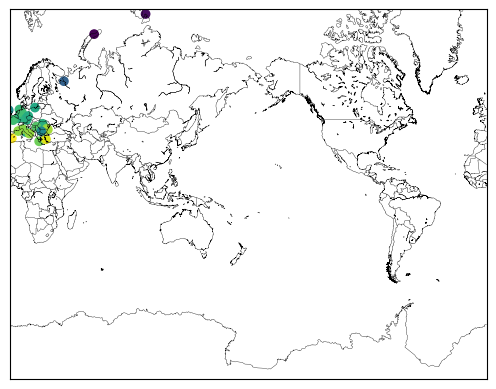

In [7]:
# First, just plot the station data so we can see where our data subset is

map = Basemap(projection='merc',llcrnrlat=-80,urcrnrlat=80,\
            llcrnrlon=0,urcrnrlon=360,lat_ts=20,resolution='l')
# draw coastlines, country boundaries, fill continents.
map.drawcoastlines(linewidth=0.25)
map.drawcountries(linewidth=0.25)

# # Add station data over the top
x2, y2 = map(points.lon, points.lat)

map.scatter(x2, y2, c=points.temperatures, cmap='viridis')

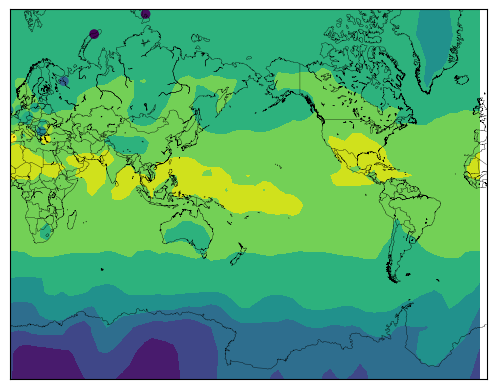

In [8]:
# Then, plot the stations over the gridded data to see the overlay

map = Basemap(projection='merc',llcrnrlat=-80,urcrnrlat=80,\
            llcrnrlon=0,urcrnrlon=360,lat_ts=20,resolution='l')
# draw coastlines, country boundaries, fill continents.
map.drawcoastlines(linewidth=0.25)
map.drawcountries(linewidth=0.25)

x, y = map(lon, lat)


# # Add station data over the top
x2, y2 = map(points.lon, points.lat)

map.contourf(x, y, data.T, cmap='viridis')
map.scatter(x2, y2, c=points.temperatures, cmap='viridis')